# 01 · Macro context: tech employment and early-career unemployment

**Question.** Did aggregate tech-sector employment and early-career labor-market outcomes deteriorate after ChatGPT's public release (30 Nov 2022), and how does the timing line up with the 2022 monetary tightening?

**Data** (all public, see `data/SOURCES.md`):
- BLS Current Employment Statistics (CES), via FRED: payrolls in Computer Systems Design (NAICS 5415) and Data Processing/Hosting (NAICS 518)
- BLS Current Population Survey (CPS), via FRED: unemployment rates by age
- Federal Reserve Bank of New York, *The Labor Market for Recent College Graduates*
- Effective federal funds rate (FRED `FEDFUNDS`), used as the main confounder

These are aggregate time series, so they describe what happened. They cannot identify AI as the cause.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().resolve().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from common import *
set_style()
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

## 1. Tech-industry payroll employment (CES)

In [2]:
ces_ids = {
    "CES6054150001": "Computer systems design (NAICS 5415)",
    "CES5051800001": "Data processing & hosting (NAICS 518)",
    "PAYEMS": "Total nonfarm",
}
ces = pd.concat([load_fred(s) for s in ces_ids], axis=1, sort=True).loc["2019":]
base = ces.loc["2022-11-01"]
ces_idx = ces / base * 100

ces_summary = pd.DataFrame({
    "Nov 2022 (thous.)": base,
    "Latest (thous.)": ces.iloc[-1],
    "Change since Nov 2022 (%)": (ces.iloc[-1] / base - 1) * 100,
    "Peak month": ces.idxmax().dt.strftime("%Y-%m"),
    "Change from peak (%)": (ces.iloc[-1] / ces.max() - 1) * 100,
}).rename(index=ces_ids)
print(f"Latest month: {ces.index[-1]:%Y-%m}")
ces_summary.round(1)

Latest month: 2026-08


,Nov 2022 (thous.),Latest (thous.),Change since Nov 2022 (%),Peak month,Change from peak (%)
Computer systems design (NAICS 5415),2482.9,2362.7,-4.8,2023-03,-4.9
Data processing & hosting (NAICS 518),483.0,453.3,-6.1,2023-08,-7.3
Total nonfarm,154242.0,159075.0,3.1,2026-08,0.0


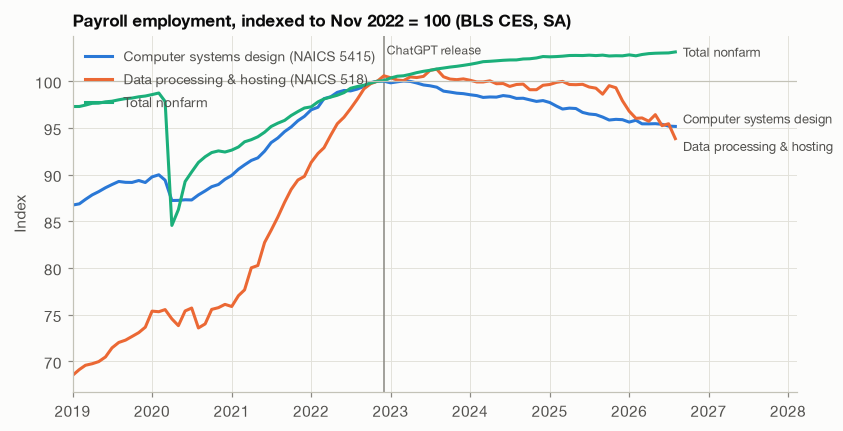

In [3]:
short = {"CES6054150001": "Computer systems design", "CES5051800001": "Data processing & hosting", "PAYEMS": "Total nonfarm"}
nudge = {"CES6054150001": 5, "CES5051800001": -5, "PAYEMS": 0}   # keep the two end labels apart
fig, ax = plt.subplots(figsize=(8.5, 4.2))
for (sid, name), c in zip(ces_ids.items(), SERIES):
    ax.plot(ces_idx.index, ces_idx[sid], color=c, label=name)
    label_end(ax, ces_idx.index[-1], ces_idx[sid].iloc[-1], short[sid], dy=nudge[sid])
ax.axhline(100, color=BASELINE, lw=0.8)
mark_chatgpt(ax)
ax.set_xlim(ces_idx.index[0], ces_idx.index[-1] + pd.Timedelta(days=560))
ax.set_title("Payroll employment, indexed to Nov 2022 = 100 (BLS CES, SA)")
ax.set_ylabel("Index")
ax.legend(loc="upper left")
save(fig, "01_ces_tech_employment");

## 2. Unemployment by age (CPS)

Annual averages (latest year is partial):


,Ages 20-24,Ages 25-34,Ages 25-54,Gap: 20-24 minus 25-54
date,,,,
2015,9.67,5.50,4.45,5.22
2016,8.42,5.06,4.16,4.26
2017,7.38,4.57,3.75,3.62
2018,6.93,3.96,3.27,3.66
2019,6.72,3.72,3.08,3.64
2020,13.95,8.47,7.13,6.82
2021,8.92,5.71,4.87,4.06
2022,7.02,3.88,3.11,3.91
2023,6.59,3.93,3.11,3.48


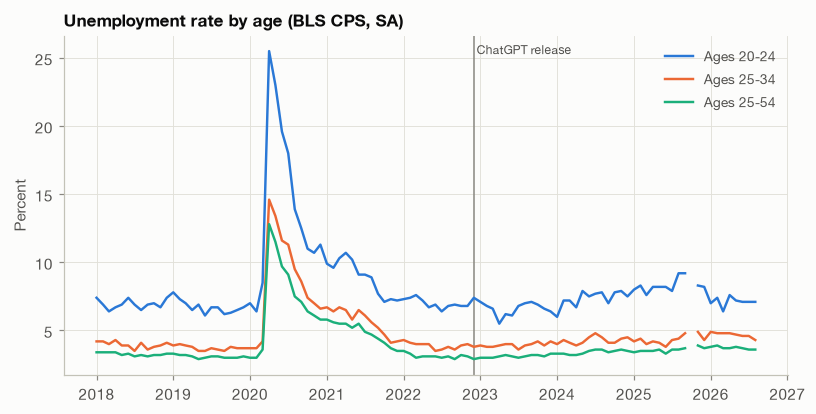

In [4]:
cps_ids = {"LNS14000036": "Ages 20-24", "LNS14000089": "Ages 25-34", "LNS14000060": "Ages 25-54"}
cps = pd.concat([load_fred(s) for s in cps_ids], axis=1, sort=True).rename(columns=cps_ids)

fig, ax = plt.subplots(figsize=(8.5, 4))
view = cps.loc["2018":]
for col, c in zip(view.columns, SERIES):
    ax.plot(view.index, view[col], color=c, label=col, lw=1.6)
mark_chatgpt(ax)
ax.set_title("Unemployment rate by age (BLS CPS, SA)")
ax.set_ylabel("Percent")
ax.legend(loc="upper right")
save(fig, "01_cps_unemployment_by_age")

cps_annual = cps.assign(**{"Gap: 20-24 minus 25-54": cps["Ages 20-24"] - cps["Ages 25-54"]}).loc["2015":].resample("YS").mean()
cps_annual.index = cps_annual.index.year
print("Annual averages (latest year is partial):")
cps_annual.round(2)

## 3. Recent college graduates (NY Fed)

NY Fed release: August 6, 2026, with 2026:Q2 data


,Young workers,All workers,Recent graduates,College graduates,Recent grads minus all workers
Date,,,,,
2000,6.31,3.76,2.77,1.77,-0.99
2001,7.09,4.42,3.72,2.30,-0.70
2002,9.10,5.58,4.60,3.06,-0.98
2003,9.55,5.81,4.46,3.19,-1.35
2004,9.05,5.34,4.28,2.90,-1.06
2005,8.32,4.89,3.97,2.49,-0.92
2006,7.66,4.49,3.55,2.20,-0.94
2007,7.93,4.41,3.43,2.14,-0.98
2008,9.69,5.39,4.05,2.59,-1.34


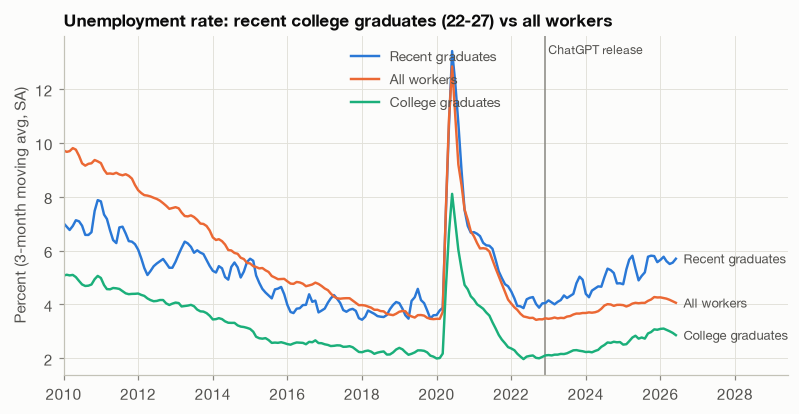

In [5]:
nymeta = json.loads((RAW / "nyfed" / "college-labor-chart-meta.json").read_text())
print("NY Fed release:", nymeta["releaseDateInfo"])

ny = pd.read_csv(RAW / "nyfed" / "college-labor-unemployment-data.csv")
ny["Date"] = pd.to_datetime(ny["Date"], format="%m/%d/%Y")
ny = ny.set_index("Date").drop(columns="NBER")
ny["Recent grads minus all workers"] = ny["Recent graduates"] - ny["All workers"]

fig, ax = plt.subplots(figsize=(8.5, 4))
view = ny.loc["2010":]
for col, c in zip(["Recent graduates", "All workers", "College graduates"], SERIES):
    ax.plot(view.index, view[col], color=c, label=col, lw=1.6)
    label_end(ax, view.index[-1], view[col].iloc[-1], col)
mark_chatgpt(ax)
ax.set_xlim(view.index[0], view.index[-1] + pd.Timedelta(days=1100))
ax.set_title("Unemployment rate: recent college graduates (22-27) vs all workers")
ax.set_ylabel("Percent (3-month moving avg, SA)")
ax.legend(loc="upper center")
save(fig, "01_nyfed_recent_grads_unemployment")

ny_annual = ny.loc["2000":].resample("YS").mean()
ny_annual.index = ny_annual.index.year
ny_annual.round(2)

74 majors ranked by recent-graduate unemployment rate (1 = highest)


,Major,Unemployment Rate,Underemployment Rate,Median Wage Early Career,Median Wage Mid-Career,Share with Graduate Degree
2,Computer Engineering,7.783,15.835,90000,131000,39.432
4,Computer Science,6.992,19.127,87000,120000,32.691


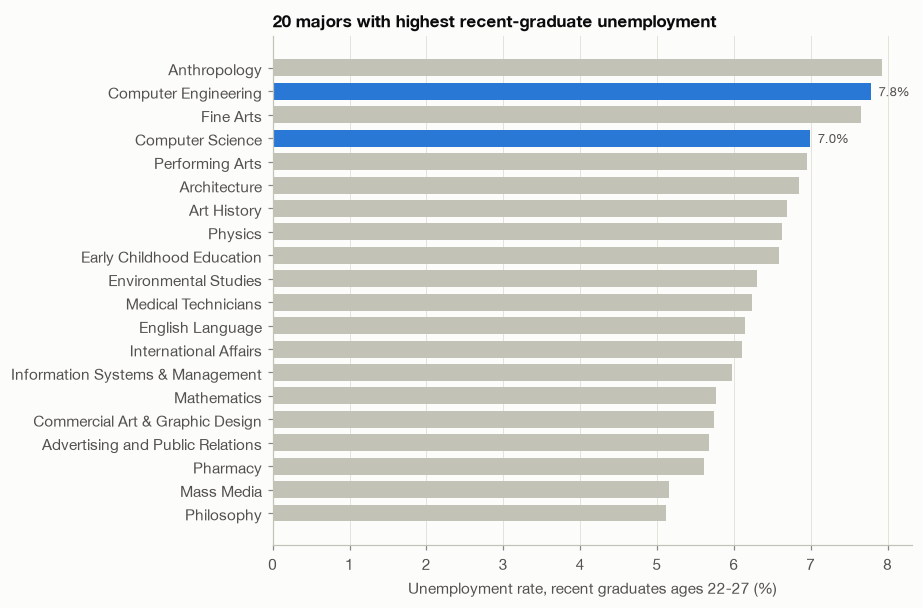

In [6]:
maj = (pd.read_csv(RAW / "nyfed" / "college-labor-outcomes-by-major-data.csv")
         .sort_values("Unemployment Rate", ascending=False).reset_index(drop=True))
maj.index = maj.index + 1
tech = ["Computer Science", "Computer Engineering"]
print(f"{len(maj)} majors ranked by recent-graduate unemployment rate (1 = highest)")
display(maj[maj.Major.isin(tech)])

top = maj.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(7.5, 6))
ax.barh(top.Major, top["Unemployment Rate"], height=0.72,
        color=[BLUE if m in tech else CONTEXT_GREY for m in top.Major])
for i, (m, v) in enumerate(zip(top.Major, top["Unemployment Rate"])):
    if m in tech:
        ax.text(v + 0.1, i, f"{v:.1f}%", va="center", fontsize=8.5, color=INK_2)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Unemployment rate, recent graduates ages 22-27 (%)")
ax.set_title("20 majors with highest recent-graduate unemployment")
save(fig, "01_nyfed_unemployment_by_major");

## 4. Confounder: monetary tightening began before ChatGPT

First rate increase of the cycle: 2022-03 (FEDFUNDS 0.20%)
FEDFUNDS in Nov 2022: 3.78%   peak: 5.33% (2023-08)


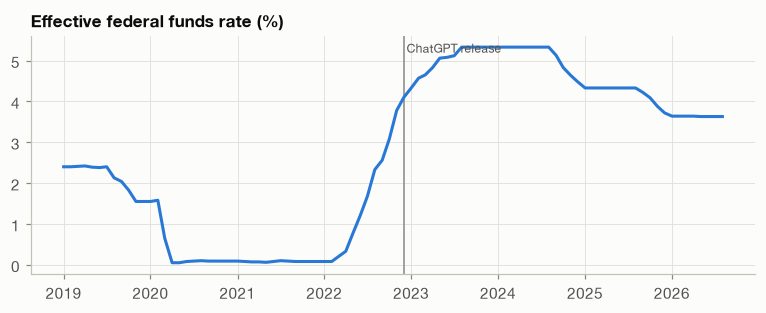

In [7]:
ff = load_fred("FEDFUNDS").loc["2019":]
first_hike = ff[(ff.diff() > 0.1) & (ff.index > "2021-12-31")].index[0]
print(f"First rate increase of the cycle: {first_hike:%Y-%m} (FEDFUNDS {ff.loc[first_hike]:.2f}%)")
print(f"FEDFUNDS in Nov 2022: {ff.loc['2022-11-01']:.2f}%   peak: {ff.max():.2f}% ({ff.idxmax():%Y-%m})")

fig, ax = plt.subplots(figsize=(8.5, 2.8))
ax.plot(ff.index, ff, color=BLUE)
mark_chatgpt(ax)
ax.set_title("Effective federal funds rate (%)")
save(fig, "01_fedfunds");

In [8]:
macro = pd.concat([ces, cps, ff.rename("FEDFUNDS")], axis=1, sort=True).loc["2019":]
macro.to_csv(PROCESSED / "macro_monthly.csv")
print("saved", PROCESSED / "macro_monthly.csv", macro.shape)

saved /Users/jeevanbhatta/Research/Tech Job Replacement/data/processed/macro_monthly.csv (92, 7)


## Findings

- **Tech-industry payrolls turned down after early 2023.** Computer Systems Design (NAICS 5415) employment peaked in March 2023. By August 2026 it was **4.9% below that peak** and 4.8% below November 2022. Data Processing & Hosting (NAICS 518) is 6.1% below November 2022. Total nonfarm payrolls grew 3.1% over the same period.
- **Broad young-worker unemployment has not clearly diverged.** The gap between ages 20–24 and 25–54 averaged 3.9 pp in 2022, 3.5 in 2023, 3.9 in 2024, 4.7 in 2025 and 3.4 in 2026 (partial year). Its 2015–2019 range was 3.6–5.2 pp.
- **Recent college graduates now fare worse than all workers.** That is historically unusual. The reversal predates ChatGPT but has widened since. From 2000 to 2017, recent graduates' unemployment ran 0.3–2.5 pp *below* the all-worker rate. The gap turned positive in 2019 (+0.3 pp), was +0.5 in 2022, and rose to +0.8 (2023), +0.9 (2024), +1.3 (2025) and +1.5 (2026 H1).
- **Computer engineering and computer science graduates have some of the highest recent-graduate unemployment of any major:** 7.8% (2nd of 74) and 7.0% (4th) in the latest NY Fed release. Their underemployment is low (16–19%).
- **Confounder.** The Fed began raising rates in March 2022. The funds rate was 3.78% when ChatGPT was released and peaked at 5.33% in August 2023. These aggregate series cannot separate AI from the rate cycle or from the unwinding of the 2021–22 tech hiring boom.